<a href="https://colab.research.google.com/github/JulianMejia6/IA_2025/blob/main/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["figure.figsize"]=(16,9)
plt.style.use("ggplot")

In [5]:
dataframe=pd.read_csv(r"/content/analisis.csv")
dataframe.head()

,usuario,op,co,ex,ag,ne,wordcount,categoria
0,3gerardpique,34.297953,28.148819,41.948819,29.370315,9.841575,37.0945,7
1,aguerosergiokun,44.986842,20.525865,37.938947,24.279098,10.362406,78.7970,7
2,albertochicote,41.733854,13.745417,38.999896,34.645521,8.836979,49.2604,4
3,AlejandroSanz,40.377154,15.377462,52.337538,31.082154,5.032231,80.4538,2
4,alfredocasero1,36.664677,19.642258,48.530806,31.138871,7.305968,47.0645,4


In [7]:
dataframe.groupby("categoria").size()

,0
categoria,
1,27
2,34
3,9
4,19
5,4
6,8
7,17
8,16
9,6


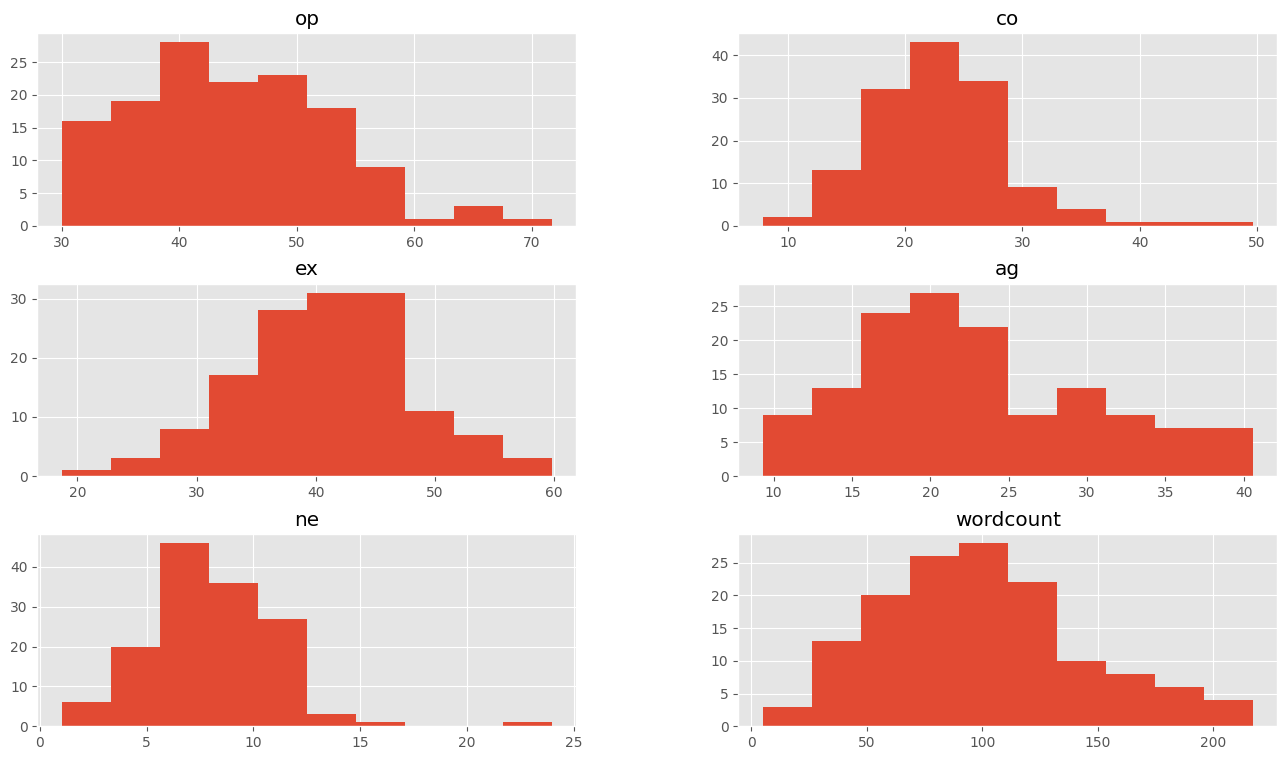

In [8]:
dataframe.drop(columns=["categoria"]).hist()
plt.show()

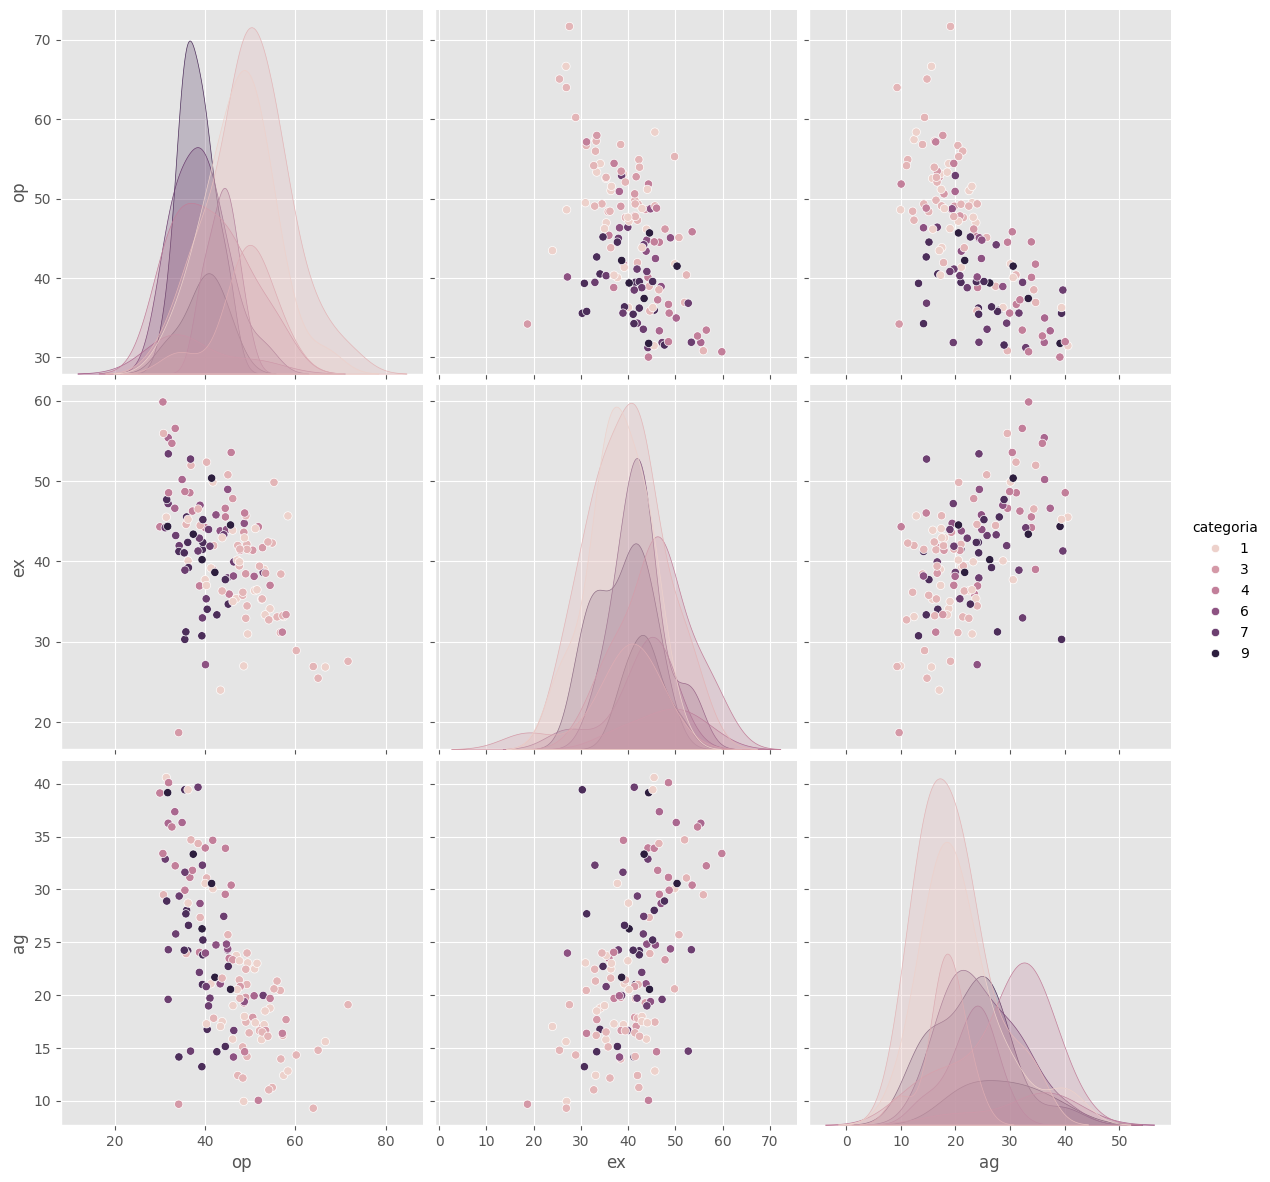

In [10]:
sb.pairplot(dataframe.dropna(),hue="categoria",height=4,vars=["op","ex","ag"],kind="scatter")

In [11]:
X=np.array(dataframe[["op", "ex", "ag"]])
Y=np.array(dataframe["categoria"])
X.shape

(140, 3)

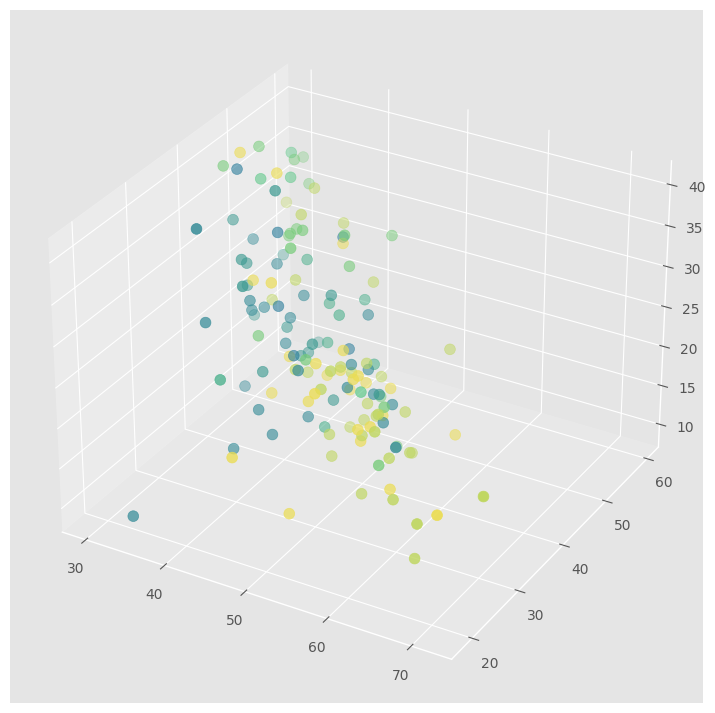

In [21]:
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
colores=["#EBDD54", "#C0D762", "#348B97", "#77CC7A", "#58C785", "#4AB08C", "#3C9A91", "#348B97", "#2A7C9A"]
asignar=[]
for row in Y:
  asignar.append(colores[row-1])
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar,s=60)
plt.show()

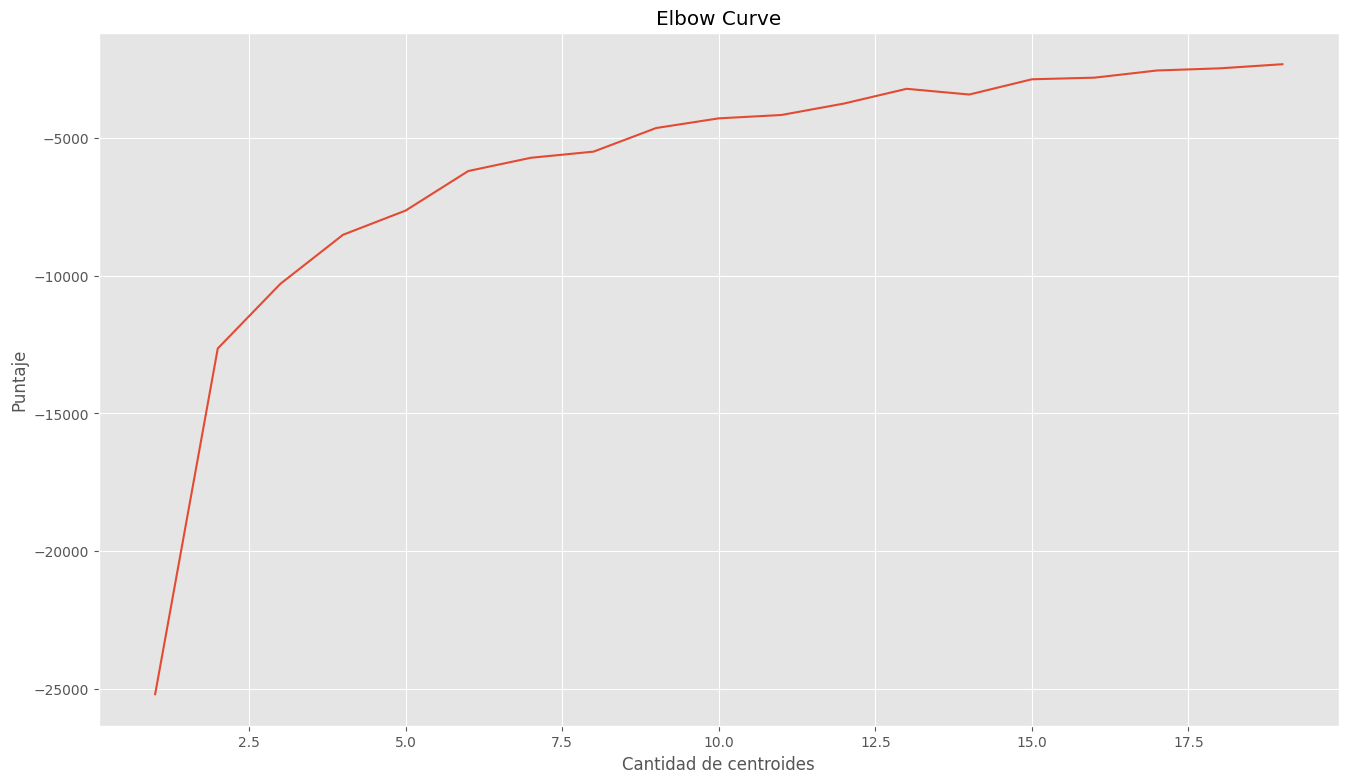

In [26]:
Nc=range(1,20)
kmeans=[KMeans(n_clusters=i) for i in Nc]
kmeans
score=[kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(Nc,score)
plt.xlabel("Cantidad de centroides")
plt.ylabel("Puntaje")
plt.title("Elbow Curve")
plt.show()

In [27]:
kmeans=KMeans(n_clusters=5).fit(X)
centroides=kmeans.cluster_centers_
print(centroides)

[[47.96207258 40.21061815 19.00696871]
 [33.82612633 49.59771714 34.58263219]
 [39.23587064 43.60398514 27.57933486]
 [58.0866237  33.25132425 15.7962078 ]
 [39.94931645 30.885978   16.83782291]]


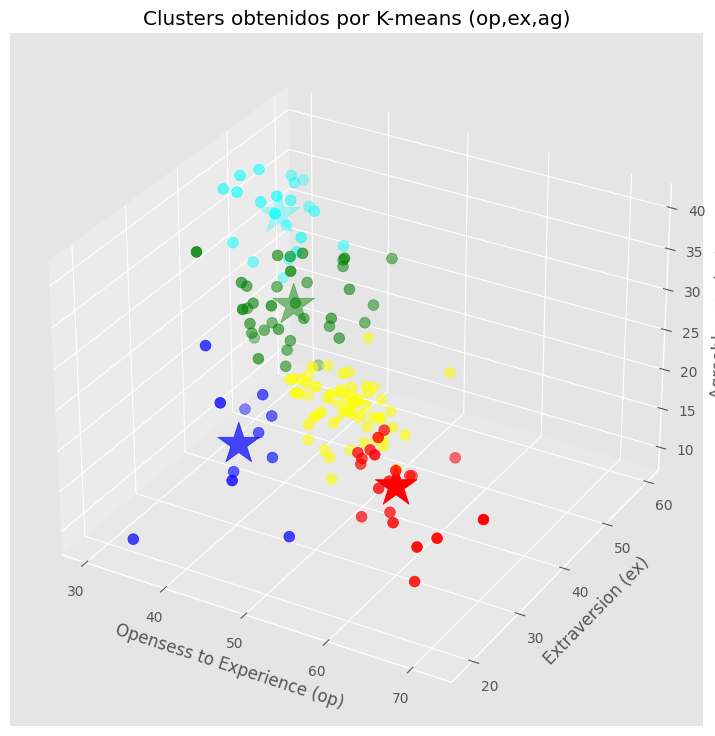

In [32]:
labels=kmeans.predict(X)
C=kmeans.cluster_centers_
colores=["yellow","cyan","green","red","blue"]
asignar=[]
for row in labels:
  asignar.append(colores[row])

fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar,s=60)
ax.scatter(C[:,0],C[:,1],C[:,2],marker="*",c=colores,s=1000)
ax.set_xlabel("Opensess to Experience (op)")
ax.set_ylabel("Extraversion (ex)")
ax.set_zlabel("Agreableness (ag)")
ax.set_title("Clusters obtenidos por K-means (op,ex,ag)")
plt.show()

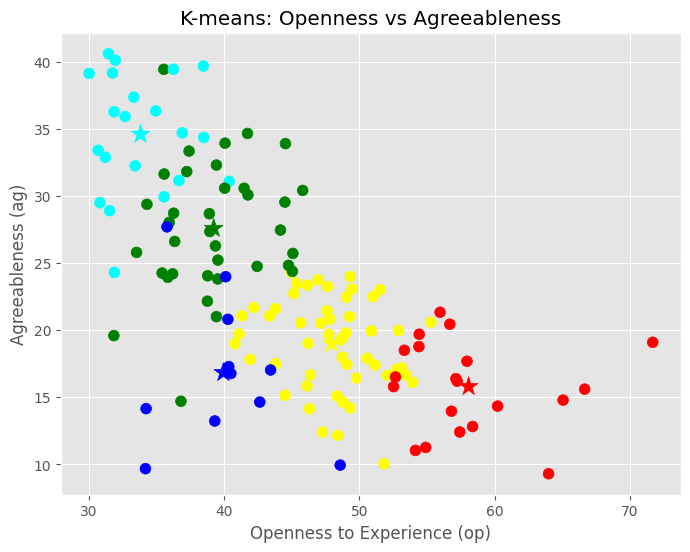

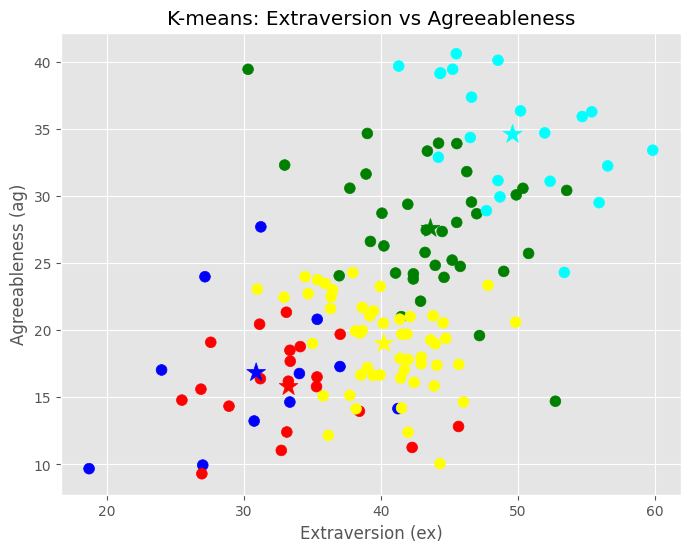

In [39]:
labels = kmeans.predict(X)
C = kmeans.cluster_centers_
colores = ["yellow", "cyan", "green", "red", "blue"]
asignar = [colores[row] for row in labels]

# --- Gráfico x vs z ---
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,2], c=asignar, s=60)
plt.scatter(C[:,0], C[:,2], marker="*", c=colores, s=200)
plt.xlabel("Openness to Experience (op)")
plt.ylabel("Agreeableness (ag)")
plt.title("K-means: Openness vs Agreeableness")
plt.show()

# --- Gráfico y vs z ---
plt.figure(figsize=(8,6))
plt.scatter(X[:,1], X[:,2], c=asignar, s=60)
plt.scatter(C[:,1], C[:,2], marker="*", c=colores, s=200)
plt.xlabel("Extraversion (ex)")
plt.ylabel("Agreeableness (ag)")
plt.title("K-means: Extraversion vs Agreeableness")
plt.show()


Text(0.5, 1.0, 'op vs ex')

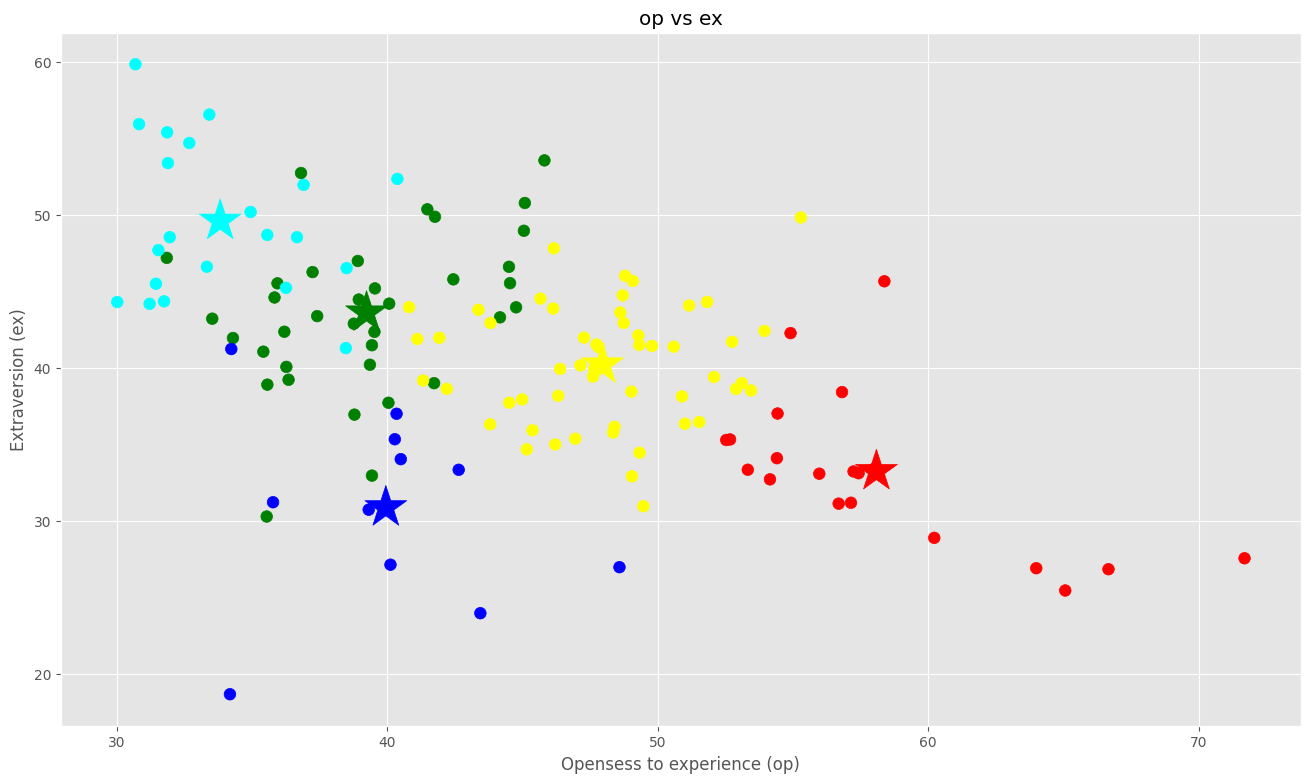

In [35]:
f1=dataframe["op"].values
f2=dataframe["ex"].values

plt.scatter(f1,f2,c=asignar,s=70)
plt.scatter(C[:,0],C[:,1],marker="*",c=colores,s=1000)
plt.xlabel("Opensess to experience (op)")
plt.ylabel("Extraversion (ex)")
plt.title("op vs ex")

In [37]:
copy=pd.DataFrame()
copy["usuario"]=dataframe["usuario"].values
copy["categoria"]=dataframe["categoria"].values
copy["label"]=labels
cantidadGrupo=pd.DataFrame()
cantidadGrupo["cantidad"]=copy.groupby("label").size()
cantidadGrupo

,cantidad
label,
0,52
1,21
2,36
3,20
4,11


In [40]:
group_referrer_index=copy["label"]==0
group_referrals=copy[group_referrer_index]

diversidadGrupo=pd.DataFrame()
diversidadGrupo["categoria"]=[0,1,2,3,4,5,6,7,8,9]
diversidadGrupo["cantidad"]=group_referrals.groupby("categoria").size()
diversidadGrupo

,categoria,cantidad
0,0,NaN
1,1,13.0
2,2,16.0
3,3,7.0
4,4,3.0
5,5,1.0
6,6,3.0
7,7,5.0
8,8,2.0
9,9,2.0


In [45]:
closest,_=pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
closest

array([93, 35, 38, 75, 60])

In [47]:
user=dataframe["usuario"].values
for row in closest:
  print(user[row])

LennyKravitz
DaniMateoAgain
David_Busta
JLo
HillaryClinton


In [53]:
X_new=np.array(([45.92,57.74,15.66]))

new_labels=kmeans.predict(X_new.reshape(1, -1))
print(new_labels)

[0]
